<a href="https://colab.research.google.com/github/bradea07/email-spam-detection/blob/main/DataMining_Project_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data"

df = pd.read_csv(url, header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


## Loading the dataset

The dataset was loaded directly from the UCI Machine Learning Repository using its public URL. The original data file does not contain column names, so the official Spambase attribute names are added manually. The last column is the target variable, where 1 means spam and 0 means non-spam.

In [ ]:
column_names = [
    "word_freq_make", "word_freq_address", "word_freq_all", "word_freq_3d",
    "word_freq_our", "word_freq_over", "word_freq_remove", "word_freq_internet",
    "word_freq_order", "word_freq_mail", "word_freq_receive", "word_freq_will",
    "word_freq_people", "word_freq_report", "word_freq_addresses",
    "word_freq_free", "word_freq_business", "word_freq_email", "word_freq_you",
    "word_freq_credit", "word_freq_your", "word_freq_font", "word_freq_000",
    "word_freq_money", "word_freq_hp", "word_freq_hpl", "word_freq_george",
    "word_freq_650", "word_freq_lab", "word_freq_labs", "word_freq_telnet",
    "word_freq_857", "word_freq_data", "word_freq_415", "word_freq_85",
    "word_freq_technology", "word_freq_1999", "word_freq_parts",
    "word_freq_pm", "word_freq_direct", "word_freq_cs", "word_freq_meeting",
    "word_freq_original", "word_freq_project", "word_freq_re",
    "word_freq_edu", "word_freq_table", "word_freq_conference",
    "char_freq_semicolon", "char_freq_parenthesis", "char_freq_bracket",
    "char_freq_exclamation", "char_freq_dollar", "char_freq_hash",
    "capital_run_length_average", "capital_run_length_longest",
    "capital_run_length_total",
    "spam"
]

df.columns = column_names
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicolon,char_freq_parenthesis,char_freq_bracket,char_freq_exclamation,char_freq_dollar,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


## Basic dataset inspection

In this step, we check the size of the dataset, the class distribution and the presence of missing values. These checks are necessary before applying machine learning models.

In [ ]:
print("Dataset shape:", df.shape)

print("\nNumber of features:", df.shape[1] - 1)
print("Number of samples:", df.shape[0])

print("\nClass distribution:")
print(df["spam"].value_counts())

print("\nClass distribution in percentages:")
print(round(df["spam"].value_counts(normalize=True) * 100, 2))

print("\nMissing values:")
print(df.isnull().sum().sum())

Dataset shape: (4601, 58)

Number of features: 57
Number of samples: 4601

Class distribution:
spam
0    2788
1    1813
Name: count, dtype: int64

Class distribution in percentages:
spam
0    60.6
1    39.4
Name: proportion, dtype: float64

Missing values:
0


The dataset contains 4601 email samples and 58 columns. There are 57 numerical input features and one target variable. The class distribution shows that 2788 emails are non-spam and 1813 emails are spam. This means that approximately 60.6% of the emails are non-spam and 39.4% are spam, so the dataset is moderately imbalanced. No missing values were found.

## Class distribution visualization

The target variable is visualized to better understand the balance between spam and non-spam emails. This is important because class imbalance can influence the performance of classification models.

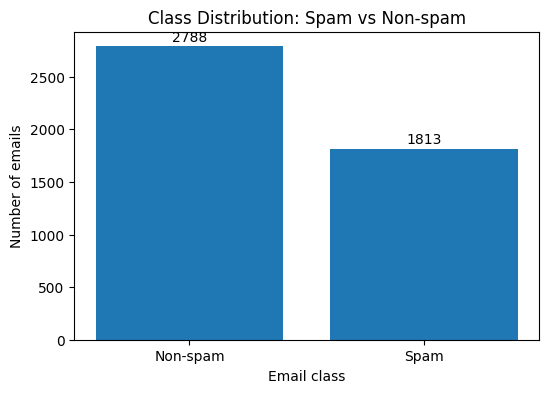

In [ ]:
plt.figure(figsize=(6, 4))

class_counts = df["spam"].value_counts().sort_index()
class_labels = ["Non-spam", "Spam"]

plt.bar(class_labels, class_counts)
plt.title("Class Distribution: Spam vs Non-spam")
plt.xlabel("Email class")
plt.ylabel("Number of emails")

for i, value in enumerate(class_counts):
    plt.text(i, value + 50, str(value), ha="center")

plt.show()

The class distribution shows that the dataset contains more non-spam emails than spam emails. However, the imbalance is not extreme: approximately 60.6% of the samples are non-spam and 39.4% are spam. Because of this, stratified train-test splitting will be used later to preserve the same class proportions in both training and testing sets.

## Statistical summary of the attributes

The following step computes descriptive statistics for the numerical attributes, including mean, standard deviation, minimum, maximum and quartile values. These statistics help describe the distribution of the feature values.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
word_freq_make,4601.0,0.104553,0.305358,0.0,0.000,0.000,0.000,4.540
word_freq_address,4601.0,0.213015,1.290575,0.0,0.000,0.000,0.000,14.280
word_freq_all,4601.0,0.280656,0.504143,0.0,0.000,0.000,0.420,5.100
word_freq_3d,4601.0,0.065425,1.395151,0.0,0.000,0.000,0.000,42.810
word_freq_our,4601.0,0.312223,0.672513,0.0,0.000,0.000,0.380,10.000
word_freq_over,4601.0,0.095901,0.273824,0.0,0.000,0.000,0.000,5.880
word_freq_remove,4601.0,0.114208,0.391441,0.0,0.000,0.000,0.000,7.270
word_freq_internet,4601.0,0.105295,0.401071,0.0,0.000,0.000,0.000,11.110
word_freq_order,4601.0,0.090067,0.278616,0.0,0.000,0.000,0.000,5.260
word_freq_mail,4601.0,0.239413,0.644755,0.0,0.000,0.000,0.160,18.180


In [ ]:
selected_features = [
    "word_freq_free",
    "word_freq_money",
    "word_freq_remove",
    "word_freq_you",
    "char_freq_exclamation",
    "char_freq_dollar",
    "capital_run_length_average",
    "capital_run_length_longest",
    "capital_run_length_total"
]

df[selected_features].describe().T

,count,mean,std,min,25%,50%,75%,max
word_freq_free,4601.0,0.248848,0.825792,0.0,0.000,0.000,0.100,20.000
word_freq_money,4601.0,0.094269,0.442636,0.0,0.000,0.000,0.000,12.500
word_freq_remove,4601.0,0.114208,0.391441,0.0,0.000,0.000,0.000,7.270
word_freq_you,4601.0,1.662100,1.775481,0.0,0.000,1.310,2.640,18.750
char_freq_exclamation,4601.0,0.269071,0.815672,0.0,0.000,0.000,0.315,32.478
char_freq_dollar,4601.0,0.075811,0.245882,0.0,0.000,0.000,0.052,6.003
capital_run_length_average,4601.0,5.191515,31.729449,1.0,1.588,2.276,3.706,1102.500
capital_run_length_longest,4601.0,52.172789,194.891310,1.0,6.000,15.000,43.000,9989.000
capital_run_length_total,4601.0,283.289285,606.347851,1.0,35.000,95.000,266.000,15841.000


## Feature visualization

Some selected features are visualized using histograms. The selected features are relevant for spam detection because words such as "free", "money", and "remove", as well as characters such as "!" and "$", are commonly associated with spam emails.

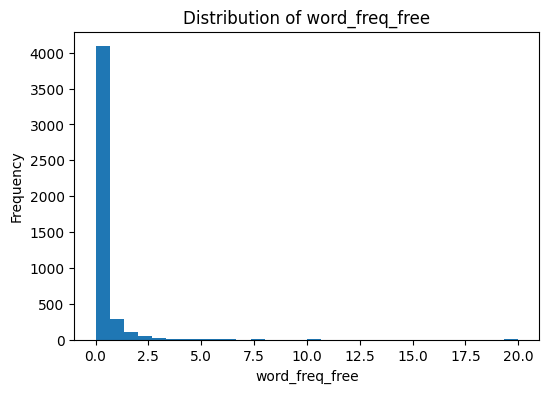

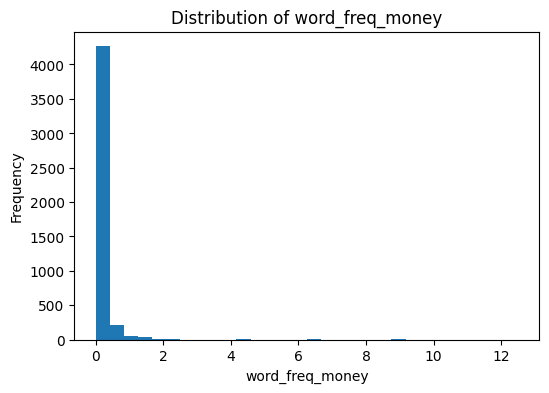

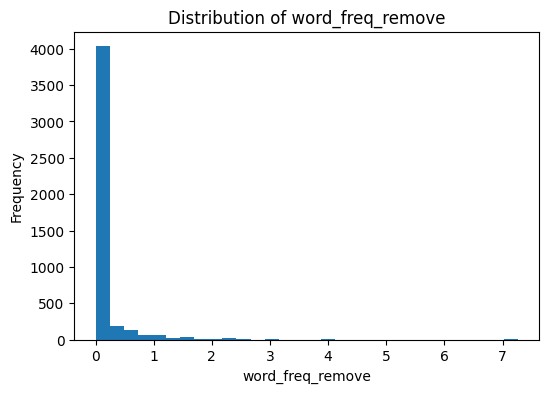

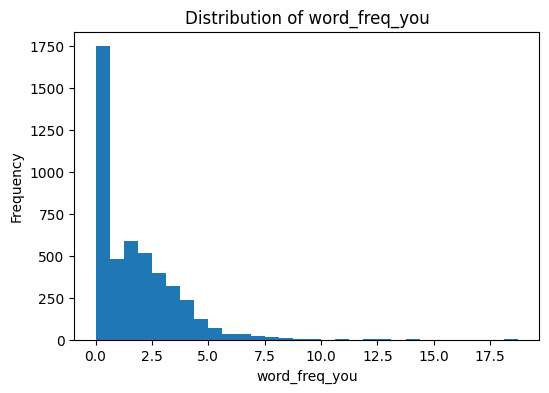

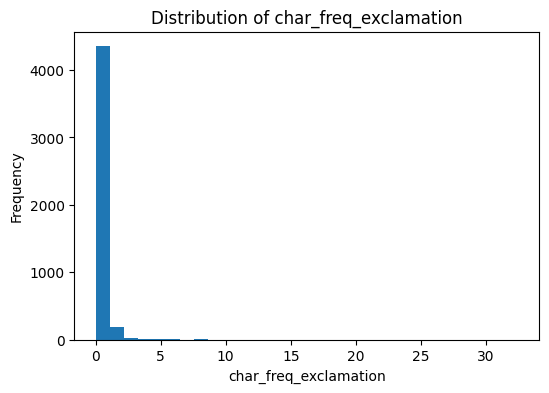

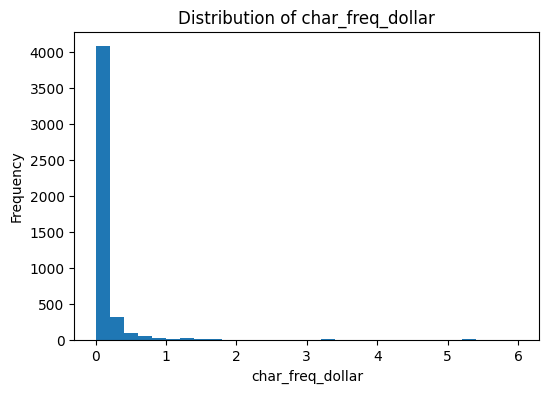

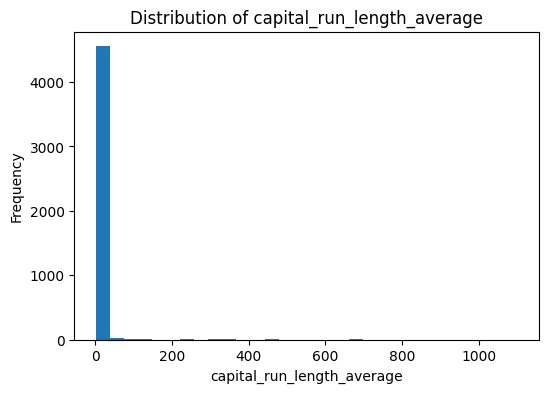

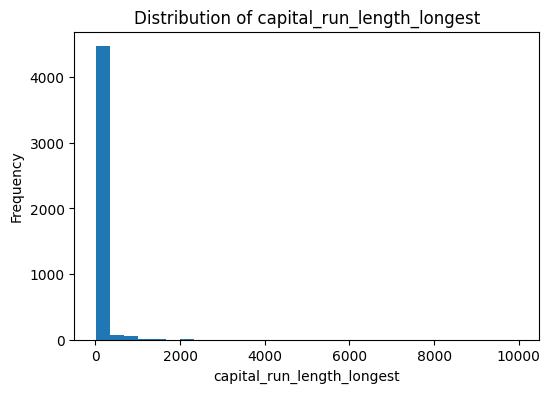

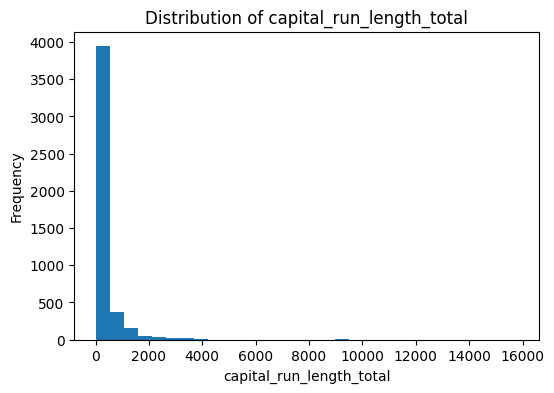

In [ ]:
selected_features = [
    "word_freq_free",
    "word_freq_money",
    "word_freq_remove",
    "word_freq_you",
    "char_freq_exclamation",
    "char_freq_dollar",
    "capital_run_length_average",
    "capital_run_length_longest",
    "capital_run_length_total"
]

for feature in selected_features:
    plt.figure(figsize=(6, 4))
    plt.hist(df[feature], bins=30)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

Many feature distributions are strongly skewed, with many values close to zero. This is expected because most emails do not contain every selected word or special character. Some features, such as capital letter sequence statistics, contain larger extreme values, which suggests that scaling is necessary before applying PCA and SVM.

## Comparison between spam and non-spam emails

Boxplots are used to compare selected feature values between spam and non-spam emails. This helps identify attributes that may be useful for classification.

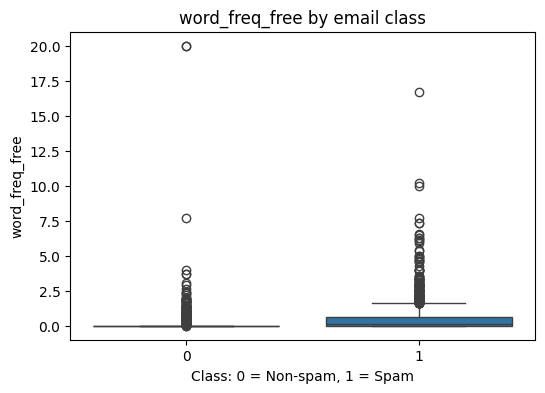

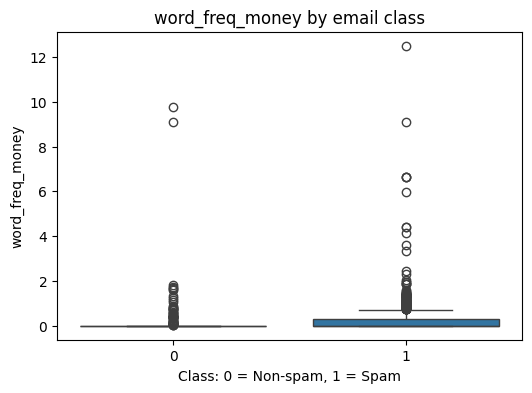

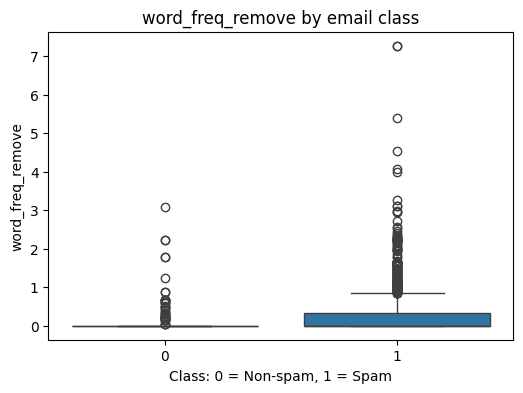

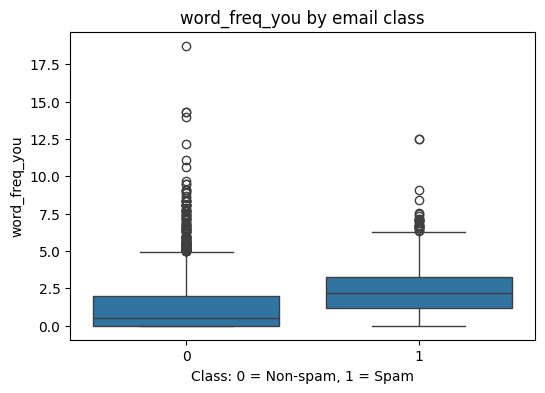

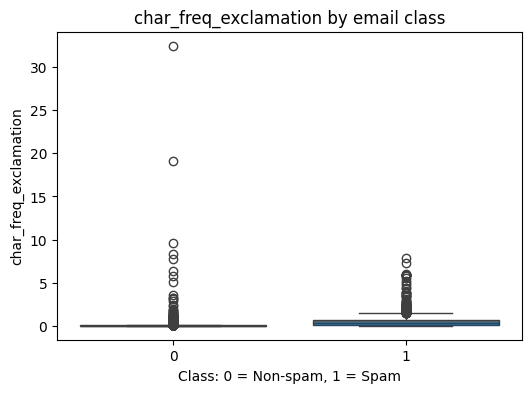

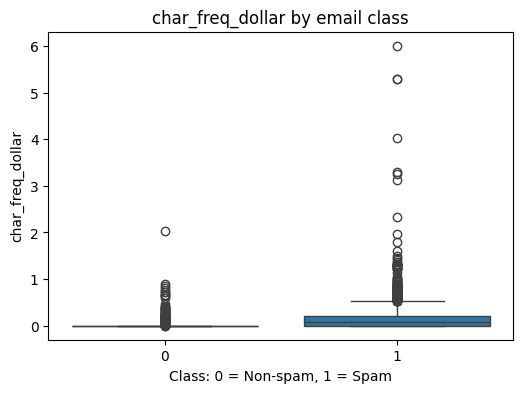

In [ ]:
for feature in selected_features[:6]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="spam", y=feature, data=df)
    plt.title(f"{feature} by email class")
    plt.xlabel("Class: 0 = Non-spam, 1 = Spam")
    plt.ylabel(feature)
    plt.show()

The boxplots show that some features have different distributions for spam and non-spam emails. For example, words such as "free", "money", and "remove", and characters such as "$" and "!" tend to appear more frequently in spam messages. This suggests that these features may be useful for classification.

## Train-test split and feature scaling

The dataset is divided into input features X and target variable y. A stratified train-test split is used to preserve the same spam/non-spam proportions in both sets. Feature scaling is applied because SVM and PCA are sensitive to the scale of the input variables.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop("spam", axis=1)
y = df["spam"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set shape: (3680, 57)
Test set shape: (921, 57)

Training class distribution:
spam
0    60.597826
1    39.402174
Name: proportion, dtype: float64

Test class distribution:
spam
0    60.586319
1    39.413681
Name: proportion, dtype: float64


The data was split into 80% training data and 20% testing data. Stratification preserved the original class proportions in both subsets. The features were standardized using StandardScaler, which transforms each feature to have approximately zero mean and unit variance on the training data.

## Baseline classification models

Two baseline classifiers are trained: Gaussian Naive Bayes and Support Vector Machine. Naive Bayes is a simple probabilistic classifier, while SVM is a stronger margin-based classifier that often performs well on numerical datasets.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

results = []

def evaluate_model(model_name, y_true, y_pred, y_proba=None):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    if y_proba is not None:
        roc_auc = roc_auc_score(y_true, y_proba)
    else:
        roc_auc = None

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })

    print(model_name)
    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1-score:", round(f1, 4))
    if roc_auc is not None:
        print("ROC-AUC:", round(roc_auc, 4))
    print("\nConfusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred))

In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred_nb = nb_model.predict(X_test_scaled)
y_proba_nb = nb_model.predict_proba(X_test_scaled)[:, 1]

evaluate_model("Naive Bayes baseline", y_test, y_pred_nb, y_proba_nb)

Naive Bayes baseline
Accuracy: 0.8328
Precision: 0.7146
Recall: 0.9587
F1-score: 0.8188
ROC-AUC: 0.9376

Confusion matrix:
[[419 139]
 [ 15 348]]

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.75      0.84       558
           1       0.71      0.96      0.82       363

    accuracy                           0.83       921
   macro avg       0.84      0.85      0.83       921
weighted avg       0.87      0.83      0.83       921



In [ ]:
svm_model = SVC(kernel="rbf", probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
y_proba_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

evaluate_model("SVM baseline", y_test, y_pred_svm, y_proba_svm)

SVM baseline
Accuracy: 0.9273
Precision: 0.9277
Recall: 0.8843
F1-score: 0.9055
ROC-AUC: 0.9667

Confusion matrix:
[[533  25]
 [ 42 321]]

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       558
           1       0.93      0.88      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.92       921
weighted avg       0.93      0.93      0.93       921



## Feature selection

Feature selection is used to keep only the most informative attributes and reduce the dimensionality of the dataset. In this project, SelectKBest with ANOVA F-score is used to select the best features. The selected features are then used to train Naive Bayes and SVM models again.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

k = 20

selector = SelectKBest(score_func=f_classif, k=k)

X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

selected_feature_names = X.columns[selector.get_support()]

print("Number of selected features:", len(selected_feature_names))
print("\nSelected features:")
for feature in selected_feature_names:
    print(feature)

Number of selected features: 20

Selected features:
word_freq_our
word_freq_over
word_freq_remove
word_freq_internet
word_freq_order
word_freq_receive
word_freq_addresses
word_freq_free
word_freq_business
word_freq_email
word_freq_you
word_freq_your
word_freq_000
word_freq_money
word_freq_hp
word_freq_hpl
char_freq_exclamation
char_freq_dollar
capital_run_length_longest
capital_run_length_total


The number of selected features was set to 20. This value keeps a reduced but still informative subset of the original 57 features. The selected attributes include word frequencies, character frequencies and capital letter sequence features that are useful for distinguishing spam from non-spam emails.

In [ ]:
nb_fs_model = GaussianNB()
nb_fs_model.fit(X_train_selected, y_train)

y_pred_nb_fs = nb_fs_model.predict(X_test_selected)
y_proba_nb_fs = nb_fs_model.predict_proba(X_test_selected)[:, 1]

evaluate_model("Naive Bayes + Feature Selection", y_test, y_pred_nb_fs, y_proba_nb_fs)

Naive Bayes + Feature Selection
Accuracy: 0.8502
Precision: 0.8814
Recall: 0.7163
F1-score: 0.7903
ROC-AUC: 0.9244

Confusion matrix:
[[523  35]
 [103 260]]

Classification report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.88       558
           1       0.88      0.72      0.79       363

    accuracy                           0.85       921
   macro avg       0.86      0.83      0.84       921
weighted avg       0.85      0.85      0.85       921



In [ ]:
svm_fs_model = SVC(kernel="rbf", probability=True, random_state=42)
svm_fs_model.fit(X_train_selected, y_train)

y_pred_svm_fs = svm_fs_model.predict(X_test_selected)
y_proba_svm_fs = svm_fs_model.predict_proba(X_test_selected)[:, 1]

evaluate_model("SVM + Feature Selection", y_test, y_pred_svm_fs, y_proba_svm_fs)

SVM + Feature Selection
Accuracy: 0.9207
Precision: 0.9119
Recall: 0.8843
F1-score: 0.8979
ROC-AUC: 0.9628

Confusion matrix:
[[527  31]
 [ 42 321]]

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       558
           1       0.91      0.88      0.90       363

    accuracy                           0.92       921
   macro avg       0.92      0.91      0.92       921
weighted avg       0.92      0.92      0.92       921



## Principal Component Analysis

Principal Component Analysis is used as a dimensionality reduction method. PCA transforms the original correlated features into a smaller number of new components while preserving most of the variance in the data. In this project, PCA is applied after feature scaling, and the number of components is chosen automatically to preserve 95% of the variance.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Number of PCA components:", X_train_pca.shape[1])
print("Explained variance ratio:", round(pca.explained_variance_ratio_.sum(), 4))

Original number of features: 57
Number of PCA components: 48
Explained variance ratio: 0.9549


The PCA transformation reduced the dimensionality of the dataset while preserving approximately 95% of the variance. This can help reduce noise and simplify the representation used by the classifiers.

In [ ]:
nb_pca_model = GaussianNB()
nb_pca_model.fit(X_train_pca, y_train)

y_pred_nb_pca = nb_pca_model.predict(X_test_pca)
y_proba_nb_pca = nb_pca_model.predict_proba(X_test_pca)[:, 1]

evaluate_model("Naive Bayes + PCA", y_test, y_pred_nb_pca, y_proba_nb_pca)

Naive Bayes + PCA
Accuracy: 0.8339
Precision: 0.7323
Recall: 0.9118
F1-score: 0.8123
ROC-AUC: 0.9266

Confusion matrix:
[[437 121]
 [ 32 331]]

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.78      0.85       558
           1       0.73      0.91      0.81       363

    accuracy                           0.83       921
   macro avg       0.83      0.85      0.83       921
weighted avg       0.85      0.83      0.84       921



In [ ]:
svm_pca_model = SVC(kernel="rbf", probability=True, random_state=42)
svm_pca_model.fit(X_train_pca, y_train)

y_pred_svm_pca = svm_pca_model.predict(X_test_pca)
y_proba_svm_pca = svm_pca_model.predict_proba(X_test_pca)[:, 1]

evaluate_model("SVM + PCA", y_test, y_pred_svm_pca, y_proba_svm_pca)

SVM + PCA
Accuracy: 0.9262
Precision: 0.9275
Recall: 0.8815
F1-score: 0.904
ROC-AUC: 0.9679

Confusion matrix:
[[533  25]
 [ 43 320]]

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       558
           1       0.93      0.88      0.90       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.92       921
weighted avg       0.93      0.93      0.93       921



## Final comparison of the models

The following table summarizes the performance of all trained models. The comparison includes baseline models, models trained after feature selection, and models trained after PCA dimensionality reduction.

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="F1-score", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,SVM baseline,0.927253,0.927746,0.884298,0.905501,0.966685
5,SVM + PCA,0.926167,0.927536,0.881543,0.903955,0.967865
3,SVM + Feature Selection,0.920738,0.911932,0.884298,0.897902,0.962785
0,Naive Bayes baseline,0.832790,0.714579,0.958678,0.818824,0.937612
6,Naive Bayes + PCA,0.833876,0.732301,0.911846,0.812270,0.926570
4,Naive Bayes + PCA,0.833876,0.732301,0.911846,0.812270,0.926570
7,Naive Bayes + PCA,0.833876,0.732301,0.911846,0.812270,0.926570
2,Naive Bayes + Feature Selection,0.850163,0.881356,0.716253,0.790274,0.924368


In [ ]:
results_df_rounded = results_df.copy()

numeric_columns = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

for col in numeric_columns:
    results_df_rounded[col] = results_df_rounded[col].round(4)

results_df_rounded

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,SVM baseline,0.9273,0.9277,0.8843,0.9055,0.9667
5,SVM + PCA,0.9262,0.9275,0.8815,0.9040,0.9679
3,SVM + Feature Selection,0.9207,0.9119,0.8843,0.8979,0.9628
0,Naive Bayes baseline,0.8328,0.7146,0.9587,0.8188,0.9376
6,Naive Bayes + PCA,0.8339,0.7323,0.9118,0.8123,0.9266
4,Naive Bayes + PCA,0.8339,0.7323,0.9118,0.8123,0.9266
7,Naive Bayes + PCA,0.8339,0.7323,0.9118,0.8123,0.9266
2,Naive Bayes + Feature Selection,0.8502,0.8814,0.7163,0.7903,0.9244


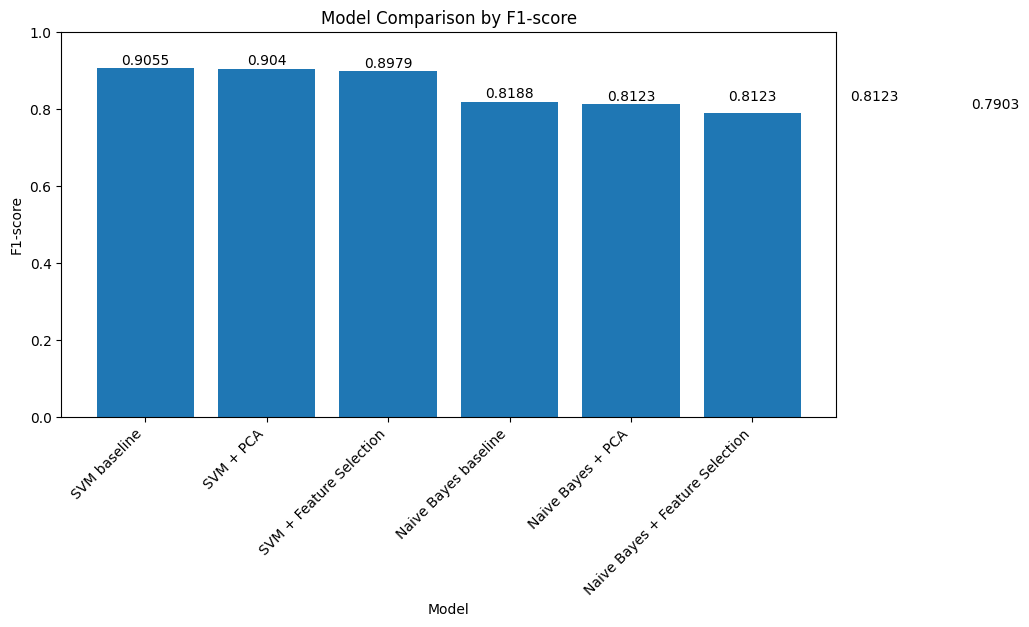

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(results_df_rounded["Model"], results_df_rounded["F1-score"])
plt.title("Model Comparison by F1-score")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)

for i, value in enumerate(results_df_rounded["F1-score"]):
    plt.text(i, value + 0.01, str(value), ha="center")

plt.show()

In [ ]:
results_df_clean = pd.DataFrame(results)

results_df_clean = results_df_clean.drop_duplicates(subset=["Model"], keep="last")
results_df_clean = results_df_clean.sort_values(by="F1-score", ascending=False)

numeric_columns = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]

for col in numeric_columns:
    results_df_clean[col] = results_df_clean[col].round(4)

results_df_clean

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,SVM baseline,0.9273,0.9277,0.8843,0.9055,0.9667
5,SVM + PCA,0.9262,0.9275,0.8815,0.9040,0.9679
3,SVM + Feature Selection,0.9207,0.9119,0.8843,0.8979,0.9628
0,Naive Bayes baseline,0.8328,0.7146,0.9587,0.8188,0.9376
7,Naive Bayes + PCA,0.8339,0.7323,0.9118,0.8123,0.9266
2,Naive Bayes + Feature Selection,0.8502,0.8814,0.7163,0.7903,0.9244


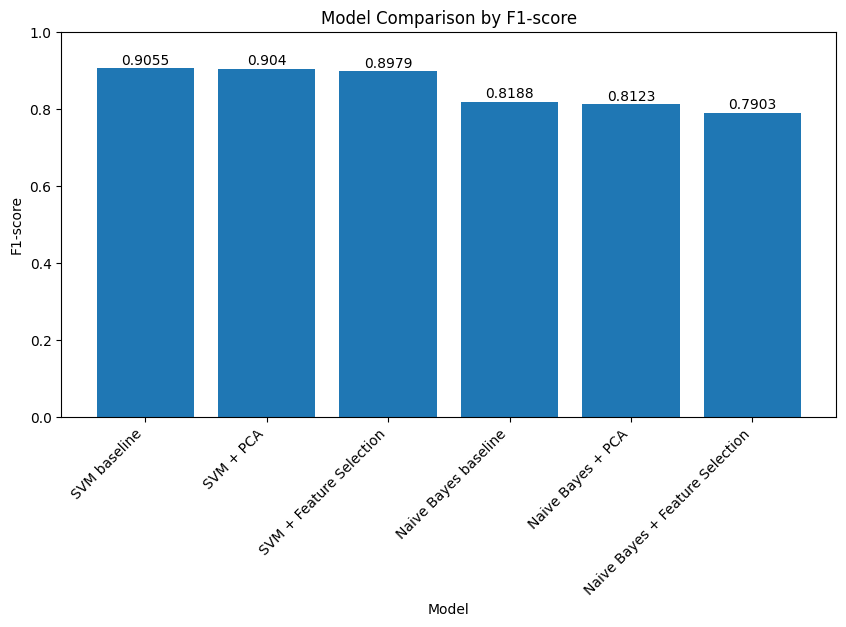

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(results_df_clean["Model"], results_df_clean["F1-score"])
plt.title("Model Comparison by F1-score")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)

for i, value in enumerate(results_df_clean["F1-score"]):
    plt.text(i, value + 0.01, str(value), ha="center")

plt.show()

## Conclusions

The best overall result was obtained by the SVM baseline model. It achieved the highest F1-score, with strong accuracy, precision, recall and ROC-AUC values.

Feature selection reduced the number of attributes and still preserved strong performance for SVM, but it did not improve over the baseline SVM model. PCA also preserved almost the same SVM performance while reducing the dimensionality from 57 original features to 48 principal components.

Naive Bayes performed reasonably well, but it was generally less balanced than SVM. Overall, SVM was the most suitable classifier for this dataset.